## Bias modelling
-----------------

In this notebook, we take a look at modelling the galaxy and magnification biases for each of the tracers.

In [1]:
import numpy as np 
import importlib
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from pathlib import Path
from scipy.integrate import simpson
from scipy.optimize import curve_fit

import src.statistics.inference as inference
import src.statistics.combination as comb
import src.statistics.cosmotools as ct
import src.statistics.corrfiles as cf
import src.statistics.sgp as sgp

In [82]:
hsc_bins = np.arange(0.3, 1.8, 0.3)

markers = ['x', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']
colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
colors = [cmap(0.8) for cmap in colormaps]

# naming conventions
tracers = ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO']
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELGnotqso' : 'ELG',
    'QSO' : 'QSO',
}

## Spectroscopic tracer galaxy bias
-----------------------------------

We fit a polynomial to the measured galaxy bias and compare with formulas given by Enrique Paillas & Edmond Chaussidon.

In [83]:
def bias_evolution(z, tracer='QSO'):
    """
    Bias model (the formula from Laurent et al. 2016 (1705.04718))
    """
    if tracer == 'QSO':
        alpha = 0.237
        beta = 2.328
    elif tracer == 'LRG':
        alpha = 0.209
        beta = 2.790
    elif tracer == 'ELG_LOPnotqso' or tracer == 'ELGnotqso':
        alpha = 0.153
        beta = 1.541
    else:
        raise NotImplementedError(f'{tracer} not implemented.')
    return bias_model(z, alpha, beta)

def bias_model(z, alpha, beta):
    """
    Bias model (the formula from Laurent et al. 2016 (1705.04718))
    """
    return alpha * ((1+z)**2 - 6.565) + beta

In [93]:
ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/')
stem = 'dr2'
path_dictionary = {
    'DESI_NGC' : ROOT / stem / f'autos_NGC',
    'DESI_SGC' : ROOT / stem / f'autos_SGC',
}
assert all([p.exists() for p in path_dictionary.values()])
autofr = cf.CorrFileReader(path_dictionary["DESI_NGC"])

In [100]:
importlib.reload(inference)
importlib.reload(ct)
bss = {t:[] for t in tracers}
bss_err = {t:[] for t in tracers}
wdm_z = []
tvalues = {}
scale_cuts = [6, 10] 
desi_redshift = np.load(ROOT.parent / 'zeff' / 'desi_z_clustering_catalogs.npy')
for t in tracers:
    tbin = autofr.get_bins(t)
    tval = (tbin[1:] + tbin[:-1])/2
    tvalues[t] = tval
    dz = np.mean(np.diff(tbin))
    for zind, z in enumerate(tval, start=1):
        w, we, cs = inference.wss(
            bin_index1=zind,
            bin_index2=zind,
            tracer1=t,
            tracer2=t,
            path_NGC=path_dictionary['DESI_NGC'],
            path_SGC=path_dictionary['DESI_SGC'],
            scale_cuts=scale_cuts,
        )
        z = desi_redshift[(tbin[zind-1] < desi_redshift) & (desi_redshift < tbin[zind])].mean()  # average redshift in the bin
        #z = np.mean(tbin[zind-1:zind+1]) 
        #z = desi_redshift[z]
        wdm_eff = ct.w_dm(
            rp_vals=np.linspace(scale_cuts[0], scale_cuts[1], 100),  # comoving separation in h^-1 Mpc
            z=z,
            integrate=True
        ) / dz
        wdm_z.append(wdm_eff)
        print(f'Bounds : {tbin[zind-1]:.3f} - {tbin[zind]:.3f}, z = {z:.3f}, w = {w:.3f}, wdm = {wdm_eff:.3f}, we = {we:.3f}')
        bss[t].append(np.sqrt(w/wdm_eff))
        bss_err[t].append(np.sqrt(
        (
            we/(2*np.sqrt(w*wdm_eff))
            )**2
        ))

Bounds : 0.000 - 0.050, z = 0.035, w = 0.074, wdm = 0.075, we = 0.019
Bounds : 0.050 - 0.100, z = 0.078, w = 0.102, wdm = 0.074, we = 0.012
Bounds : 0.100 - 0.150, z = 0.127, w = 0.094, wdm = 0.072, we = 0.006
Bounds : 0.150 - 0.200, z = 0.176, w = 0.098, wdm = 0.071, we = 0.005
Bounds : 0.200 - 0.250, z = 0.225, w = 0.107, wdm = 0.069, we = 0.005
Bounds : 0.250 - 0.300, z = 0.274, w = 0.120, wdm = 0.068, we = 0.005
Bounds : 0.300 - 0.350, z = 0.324, w = 0.132, wdm = 0.066, we = 0.005
Bounds : 0.350 - 0.400, z = 0.373, w = 0.139, wdm = 0.065, we = 0.004
Bounds : 0.400 - 0.450, z = 0.423, w = 0.158, wdm = 0.064, we = 0.004
Bounds : 0.450 - 0.500, z = 0.474, w = 0.173, wdm = 0.063, we = 0.005
Bounds : 0.500 - 0.550, z = 0.526, w = 0.187, wdm = 0.061, we = 0.006
Bounds : 0.550 - 0.600, z = 0.575, w = 0.225, wdm = 0.060, we = 0.010
Bounds : 0.300 - 0.350, z = 0.324, w = 0.177, wdm = 0.066, we = 0.008
Bounds : 0.350 - 0.400, z = 0.373, w = 0.207, wdm = 0.065, we = 0.007
Bounds : 0.400 - 0.4

Bias evolution for BGS_ANY not implemented, skipping.
BGS_ANY: alpha = 0.601 ± 0.025, beta = 4.299 ± 0.116
LRG: alpha = 0.245 ± 0.009, beta = 2.965 ± 0.031
ELGnotqso: alpha = 0.153 ± 0.005, beta = 1.699 ± 0.011
QSO: alpha = 0.192 ± 0.005, beta = 2.300 ± 0.011


(0.5, 5.0)

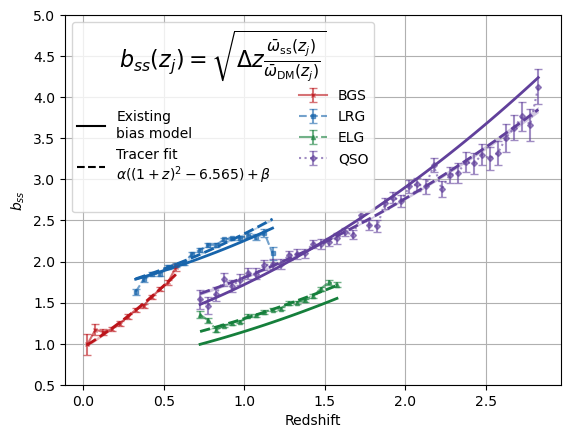

In [101]:
for indt, t in enumerate(tracers):
    bss[t] = np.array(bss[t])
    bss_err[t] = np.array(bss_err[t])
    tvalues[t] = np.array(tvalues[t])
    indt = tracers.index(t)

    # Plot measurements with error bars
    plt.errorbar(
        tvalues[t],
        bss[t], 
        yerr=bss_err[t], 
        marker=markers[indt],
        markersize=3,
        label=tracer_trad[t], 
        color=colors[indt],
        linestyle=linestyles[indt], 
        capsize=3,
        alpha=0.6,
    )

    # plot empty lines for legend
    if indt == 0:
        plt.plot([], [], label=f' ', alpha=0)
        plt.plot(
            [], 
            [], 
            color='black', 
            label=f'Existing\nbias model'
            )
        plt.plot(
            [], 
            [], 
            color='black', 
            linestyle='--', 
            label=(
                f'Tracer fit\n'
                + r'$\alpha((1+z)^2 - 6.565) + \beta$'
            )
            )
        plt.plot([], [], label=f' ', alpha=0)

    try:
        plt.plot(
            tvalues[t], 
            bias_evolution(tvalues[t], tracer=t), 
            color=colors[indt], 
            linestyle='-', 
            linewidth=2,
        )
    except NotImplementedError:
        print(f'Bias evolution for {t} not implemented, skipping.')

    popt, pcov = curve_fit(
        bias_model,
        tvalues[t],
        bss[t],
        sigma=bss_err[t],
        absolute_sigma=True,
        p0=[1.0, 1.0]
    )

    alpha_fit, beta_fit = popt
    alpha_err, beta_err = np.sqrt(np.diag(pcov))
    print(f'{t}: alpha = {alpha_fit:.3f} ± {alpha_err:.3f}, beta = {beta_fit:.3f} ± {beta_err:.3f}')

    z_fit = np.linspace(min(tvalues[t]), max(tvalues[t]), 200)
    y_fit = bias_model(z_fit, *popt)

    # error propagation for the fit
    J_alpha = (1 + z_fit)**2 - 6.565
    J_beta = np.ones_like(z_fit)
    y_err = np.sqrt(
        J_alpha**2 * pcov[0, 0] +
        J_beta**2 * pcov[1, 1] +
        2 * J_alpha * J_beta * pcov[0, 1]
    )

    plt.plot(
        z_fit,
        y_fit,
        color=colors[indt],
        linestyle='--',
        linewidth=2,
    )

    plt.fill_between(
        z_fit,
        y_fit - y_err,
        y_fit + y_err,
        color=colors[indt],
        alpha=0.3,
        linewidth=0,
    )

plt.xlabel('Redshift')
plt.ylabel(r'$b_{ss}$')
plt.legend(
    loc='upper left', 
    ncol=2, 
    fontsize=10,
    title=r'$b_{ss}(z_j)=\sqrt{\Delta z\frac{\bar{\omega}_{\mathrm{ss}}(z_j)}{\bar{\omega}_{\mathrm{DM}}(z_j)}}$',
    title_fontsize=16,
)
plt.grid()
plt.ylim(0.5, 5)

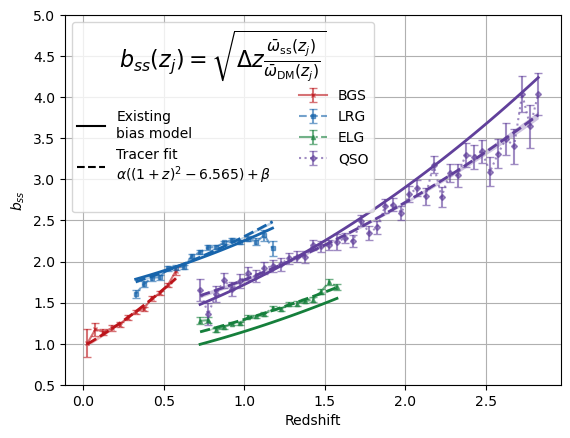

## Galaxy bias model for HSC
-----------------------------

In [26]:
wdm_z = []
z_wdm = np.linspace(0.1, 3, 31)
for z in z_wdm:
    wdm = ct.w_dm(
        rp_vals=np.linspace(scale_cuts[0], scale_cuts[1], 101),  # comoving separation in h^-1 Mpc
        z=z,
        integrate=True
    )
    wdm_z.append(wdm/dz) # integrate to compare with wss if needed
wdm_z = np.array(wdm_z)

WDM fit: a = 0.598 ± 0.002, b = -1.168 ± 0.006


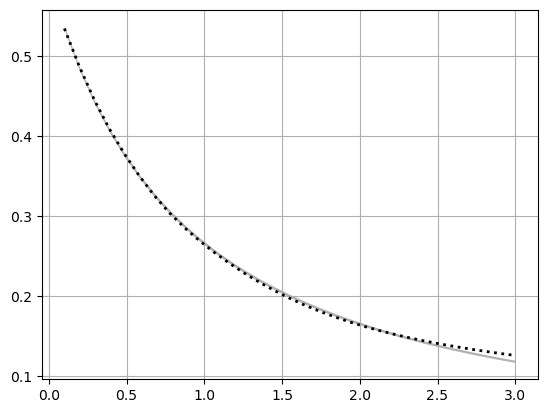

In [27]:
plt.plot(z_wdm, wdm_z, color='black', linestyle=':', linewidth=2, label='DM model')
# fit a power law to the wdm_z
def power_law(z, a, b):
    return a * (1+z)**b
popt, pcov = curve_fit(
    power_law,
    z_wdm,
    wdm_z,
    p0=[1.0, 1.0]
)
a_fit, b_fit = popt
a_err, b_err = np.sqrt(np.diag(pcov))
print(f'WDM fit: a = {a_fit:.3f} ± {a_err:.3f}, b = {b_fit:.3f} ± {b_err:.3f}')
plt.fill_between(
    z_wdm,
    power_law(z_wdm, a_fit - a_err, b_fit - b_err),
    power_law(z_wdm, a_fit + a_err, b_fit + b_err),
    color='black',
    alpha=0.3,
    linewidth=0,
)
plt.grid()

## Magnification bias
---------------------

Text(0, 0.5, '$\\alpha(z)=2.5s_{\\mu}(z)-1$ (DR1)')

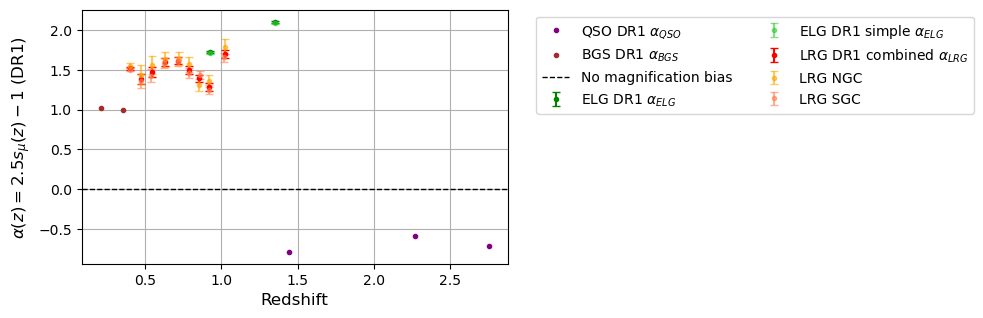

In [ ]:
plt.figure(figsize=(5.5, 3.3))
average_lrg = False
show_alpha = True
## QSO : Cosmology from Planck CMB Lensing and DESI DR1 Quasar Tomography (CWR)
pz_qso_edges = np.array([0.8, 2.1, 2.5, 3.5])
pz_qso = [1.44, 2.27, 2.75]
qso_mag = {
    "s": np.array([
        0.0820,
        0.1634,
        0.1109
    ]),
}
plt.plot(
    pz_qso, 
    2.5*qso_mag['s']-1 if show_alpha else qso_mag['s'],
    marker='o', 
    markersize=3, 
    label=r'QSO DR1 $\alpha_{QSO}$' if show_alpha else r'QSO DR1 $s_{QSO}$',
    color='purple', 
    linestyle='', 
)


## ELG : from Sven Heydenreich
elg_mag = {
        "simple_alphas": [
            1.710457201775925,
            2.085457557991333
        ],
        "simple_alphas_error": [
            0.008508155984175739,
            0.00947690517516168
        ],
        "alphas": [
            1.7223330925515012,
            2.1021482852604767
        ],
        "alphas_error": [
            0.009850409808008864,
            0.010948105366427699
        ]
    }
pz_cuts_ELG_edges = np.array([0.7, 1.15, 1.55])
pz_cuts_ELG = (pz_cuts_ELG_edges[1:] + pz_cuts_ELG_edges[:-1]) / 2
plt.errorbar(
    pz_cuts_ELG, 
    np.array(elg_mag['alphas']) if show_alpha else (1+np.array(elg_mag['alphas']))/2.5,
    yerr=np.array(elg_mag['alphas_error']) if show_alpha else (np.array(elg_mag['alphas_error']))/2.5,
    marker='o', 
    markersize=3, 
    label=r'ELG DR1 $\alpha_{ELG}$' if show_alpha else r'ELG DR1 $s_{ELG}$', 
    color='green', 
    linestyle='', 
    capsize=3,
)
plt.errorbar(
    pz_cuts_ELG, 
    np.array(elg_mag['simple_alphas']) if show_alpha else (1+np.array(elg_mag['simple_alphas']))/2.5,
    yerr=np.array(elg_mag['simple_alphas_error']) if show_alpha else (np.array(elg_mag['simple_alphas_error']))/2.5,
    marker='o', 
    markersize=3, 
    label=r'ELG DR1 simple $\alpha_{ELG}$' if show_alpha else r'ELG DR1 simple $s_{ELG}$',
    color='limegreen', 
    linestyle='', 
    capsize=3,
    alpha=0.6,
)

## LRG : from DR1 by Rongpu Zhou in small redshift bins.
# Main sample
pz_cuts_south_LRG = np.array([0.4, 0.47, 0.54, 0.6265, 0.713, 0.7865, 0.86, 0.92, 1.02])
pz_cuts_north_LRG = np.array([0.4, 0.4725, 0.545, 0.632, 0.719, 0.785, 0.851, 0.92, 1.024])
pz_cuts_combined_LRG = (pz_cuts_north_LRG + pz_cuts_south_LRG) / 2

north_s_LRG        = np.array([1.021, 0.976, 1.024, 1.053, 1.056, 1.029, 0.925, 0.944, 1.116])
north_s_LRG_err    = np.array([0.012, 0.049, 0.045, 0.037, 0.033, 0.038, 0.030, 0.032, 0.038])

south_s_LRG        = np.array([1.001, 0.944, 0.971, 1.034, 1.043, 0.986, 0.972, 0.899, 1.063])
south_s_LRG_err    = np.array([0.008, 0.033, 0.031, 0.026, 0.022, 0.025, 0.020, 0.023, 0.024])

combined_s_LRG     = np.array([1.008, 0.954, 0.988, 1.040, 1.047, 0.999, 0.957, 0.914, 1.078])
combined_s_LRG_err = np.array([0.007, 0.027, 0.025, 0.021, 0.018, 0.021, 0.017, 0.018, 0.020])

plt.errorbar(
    pz_cuts_combined_LRG, 
    2.5*combined_s_LRG-1 if show_alpha else combined_s_LRG,
    yerr=2.5*combined_s_LRG_err if show_alpha else combined_s_LRG_err, 
    marker='o', 
    markersize=3, 
    label=r'LRG DR1 combined $\alpha_{LRG}$' if show_alpha else r'LRG DR1 combined $s_{LRG}$', 
    color='red', 
    linestyle='', 
    capsize=3,
)

plt.errorbar(
    pz_cuts_north_LRG, 
    2.5*north_s_LRG-1 if show_alpha else north_s_LRG,
    yerr=2.5*north_s_LRG_err if show_alpha else north_s_LRG_err, 
    marker='o', 
    markersize=3, 
    label='LRG NGC', 
    color='orange', 
    linestyle='', 
    capsize=3,
    alpha=0.6,
)
plt.errorbar(
    pz_cuts_south_LRG, 
    2.5*south_s_LRG-1 if show_alpha else south_s_LRG,
    yerr=2.5*south_s_LRG_err if show_alpha else south_s_LRG_err, 
    marker='o', 
    markersize=3, 
    label='LRG SGC', 
    color='coral', 
    linestyle='', 
    capsize=3,
    alpha=0.6,
)
#average of combined with error-bar weighting
if average_lrg:
    val = np.average(combined_s_LRG, weights=1/combined_s_LRG_err**2)
    val_err = np.sqrt(1/np.sum(1/combined_s_LRG_err**2))
    plt.fill_between(
        pz_cuts_combined_LRG, 
        2.5*(val-val_err)-1 if show_alpha else val-val_err, 
        2.5*(val+val_err)-1 if show_alpha else val+val_err, 
        color='red', 
        label=(
            r'Weighted constant $\alpha_{LRG}$' 
            + '\n' + rf'$\alpha_{{LRG}} = {2.5*val-1:.3f} \pm {2.5*val_err:.3f}$'
            ) if show_alpha else (
            r'Weighted constant $s_{LRG}$'
            + '\n' + rf'$s_{{LRG}} = {val:.3f} \pm {val_err:.3f}$'
            ),
        alpha=0.3, 
        linewidth=0,
    )
## BGS
pz_cuts_BGS = np.array([0.211, 0.352])
s_bgs = np.array([0.81, 0.80])
plt.plot(
    pz_cuts_BGS, 
    2.5*s_bgs-1 if show_alpha else s_bgs,
    marker='o', 
    markersize=3, 
    label=r'BGS DR1 $\alpha_{BGS}$' if show_alpha else r'BGS DR1 $s_{BGS}$',
    color='brown', 
    linestyle='', 
)
plt.axhline(
    y=0 if show_alpha else 0.4, 
    color='black', 
    linestyle='--', 
    linewidth=1, 
    label='No magnification bias'
)
#plt.xlim(0.35, 1.1)
#plt.ylim(0.5, 2)
plt.grid() 
plt.legend(loc='upper left', fontsize=10, ncols=2, bbox_to_anchor=(1.05, 1))
plt.xlabel('Redshift', fontsize=12)
plt.ylabel(r'$\alpha(z)=2.5s_{\mu}(z)-1$ (DR1)' if show_alpha else r'$s_{\mu}(z)$ (DR1)', fontsize=12)